# Phase 3: Synthetic Data Generation (CTGAN & TVAE)

This notebook:
1. Conditionally executes the synthetic data generation script `scripts/generate_synthetic.py`.
2. Validates that the generated synthetic datasets match the real training splits in schema, dimensions, and columns.
3. Compares the target class distribution (credit default rates) of the synthetic data against the real baseline.
4. Plots continuous feature marginal distributions to inspect synthetic data representation.

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## 1. Run Generation Script

We run the generation loop if the synthetic datasets do not exist.

In [2]:
ctgan_sample_file = "../../data/synthetic/german_credit_ctgan_seed42.csv"
if not os.path.exists(ctgan_sample_file):
    print("Running synthetic generation script (python scripts/generate_synthetic.py)...")
    import subprocess
    subprocess.run([sys.executable, "../../scripts/generate_synthetic.py"], check=True)
else:
    print("Synthetic datasets already exist. Skipping training and sampling (using cached files).")

Synthetic datasets already exist. Skipping training and sampling (using cached files).


## 2. Verify Schema and Dimensions

We load the generated files for Seed 42 and compare their structures against the real training splits.

In [3]:
def verify_dataset_pair(dataset_name, raw_path, target_col, seed=42):
    # Load real raw data and reconstruct raw train split
    df_real_raw = pd.read_csv(raw_path)
    if dataset_name == "gmsc" and "Unnamed: 0" in df_real_raw.columns:
        df_real_raw = df_real_raw.drop(columns=["Unnamed: 0"])
        
    real_train_df, _ = train_test_split(
        df_real_raw, test_size=0.3, stratify=df_real_raw[target_col], random_state=seed
    )
    
    # Load synthetic datasets
    df_ctgan = pd.read_csv(f"../../data/synthetic/{dataset_name}_ctgan_seed{seed}.csv")
    df_tvae = pd.read_csv(f"../../data/synthetic/{dataset_name}_tvae_seed{seed}.csv")
    
    print(f"=== {dataset_name.upper()} DATASET SHAPES (Seed {seed}) ===")
    print(f"Real Train Split: {real_train_df.shape}")
    print(f"CTGAN Synthetic:  {df_ctgan.shape}")
    print(f"TVAE Synthetic:   {df_tvae.shape}")
    
    # Schema assertions
    assert real_train_df.shape == df_ctgan.shape, "CTGAN shape mismatch!"
    assert real_train_df.shape == df_tvae.shape, "TVAE shape mismatch!"
    assert list(real_train_df.columns) == list(df_ctgan.columns), "CTGAN column names or order mismatch!"
    assert list(real_train_df.columns) == list(df_tvae.columns), "TVAE column names or order mismatch!"
    
    print("Schema check: PASSED (Shapes and columns match perfectly!)\n")
    return real_train_df, df_ctgan, df_tvae

german_real, german_ctgan, german_tvae = verify_dataset_pair(
    "german_credit", "../../data/raw/german_credit.csv", "class"
)

gmsc_real, gmsc_ctgan, gmsc_tvae = verify_dataset_pair(
    "gmsc", "../../data/raw/gmsc_sampled_10k.csv", "SeriousDlqin2yrs"
)

=== GERMAN_CREDIT DATASET SHAPES (Seed 42) ===
Real Train Split: (700, 21)
CTGAN Synthetic:  (700, 21)
TVAE Synthetic:   (700, 21)
Schema check: PASSED (Shapes and columns match perfectly!)

=== GMSC DATASET SHAPES (Seed 42) ===
Real Train Split: (7000, 11)
CTGAN Synthetic:  (7000, 11)
TVAE Synthetic:   (7000, 11)
Schema check: PASSED (Shapes and columns match perfectly!)



## 3. Compare Target Class Distribution

We check the ratio of positive class (default risk) in the synthetic datasets versus the real training split.

In [4]:
def print_class_distribution(dataset_name, df_real, df_ctgan, df_tvae, target_col, pos_label):
    r_counts = df_real[target_col].value_counts(normalize=True)
    c_counts = df_ctgan[target_col].value_counts(normalize=True)
    t_counts = df_tvae[target_col].value_counts(normalize=True)
    
    print(f"=== {dataset_name.upper()} TARGET DISTRIBUTION (Pos Label: {pos_label}) ===")
    print(f"Real Train: {r_counts.get(pos_label, 0):.4f} ({pos_label} ratio)")
    print(f"CTGAN:      {c_counts.get(pos_label, 0):.4f} ({pos_label} ratio)")
    print(f"TVAE:       {t_counts.get(pos_label, 0):.4f} ({pos_label} ratio)\n")

print_class_distribution("german_credit", german_real, german_ctgan, german_tvae, "class", "bad")
print_class_distribution("gmsc", gmsc_real, gmsc_ctgan, gmsc_tvae, "SeriousDlqin2yrs", 1)

=== GERMAN_CREDIT TARGET DISTRIBUTION (Pos Label: bad) ===
Real Train: 0.3000 (bad ratio)
CTGAN:      0.2429 (bad ratio)
TVAE:       0.0700 (bad ratio)

=== GMSC TARGET DISTRIBUTION (Pos Label: 1) ===
Real Train: 0.0669 (1 ratio)
CTGAN:      0.1691 (1 ratio)
TVAE:       0.0153 (1 ratio)



## 4. Plot Continuous Marginal Distributions

We visualize select continuous features comparing the real training set, CTGAN, and TVAE datasets.

C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(german_real['age'], label='Real', shade=True, color='blue')
C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:4: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(german_ctgan['age'], label='CTGAN', shade=True, color='orange')
C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:5: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(german_tvae['age'], label='TVAE', shade=True, color='green')


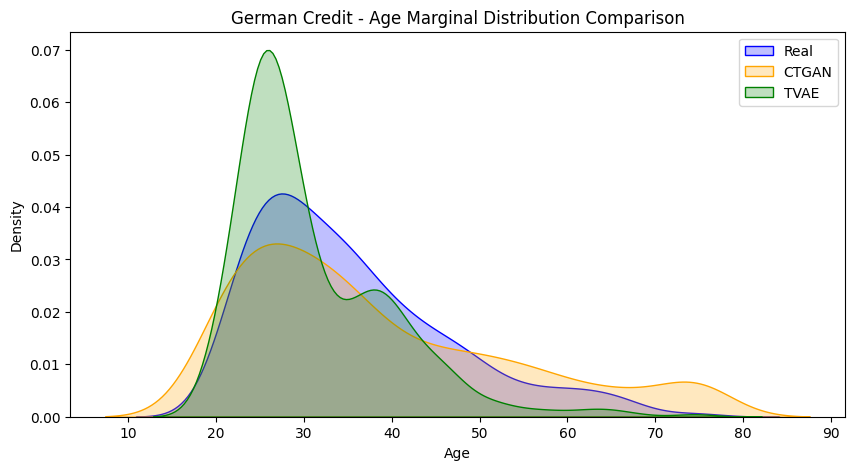

C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:15: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(gmsc_real[gmsc_real['DebtRatio'] <= clip_val]['DebtRatio'], label='Real', shade=True, color='blue')
C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:16: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(gmsc_ctgan[gmsc_ctgan['DebtRatio'] <= clip_val]['DebtRatio'], label='CTGAN', shade=True, color='orange')
C:\Users\Isha\AppData\Local\Temp\ipykernel_26220\314460397.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(gmsc_tvae[gmsc_tvae['DebtRatio'] <= clip_val]['DebtRatio'], label='TVAE', shade=True, c

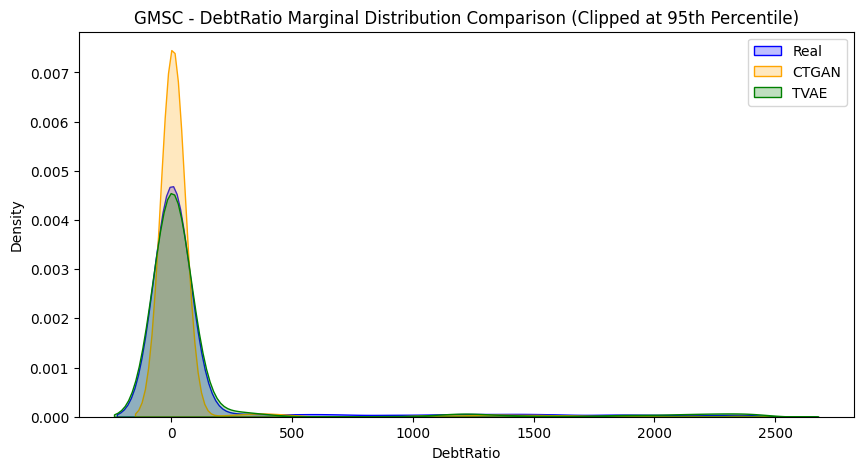

In [5]:
# Plotting Age distribution in German Credit
plt.figure(figsize=(10, 5))
sns.kdeplot(german_real['age'], label='Real', shade=True, color='blue')
sns.kdeplot(german_ctgan['age'], label='CTGAN', shade=True, color='orange')
sns.kdeplot(german_tvae['age'], label='TVAE', shade=True, color='green')
plt.title('German Credit - Age Marginal Distribution Comparison')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

# Plotting DebtRatio in GMSC (clipped to 99th percentile for visual comparison)
plt.figure(figsize=(10, 5))
clip_val = gmsc_real['DebtRatio'].quantile(0.95)
sns.kdeplot(gmsc_real[gmsc_real['DebtRatio'] <= clip_val]['DebtRatio'], label='Real', shade=True, color='blue')
sns.kdeplot(gmsc_ctgan[gmsc_ctgan['DebtRatio'] <= clip_val]['DebtRatio'], label='CTGAN', shade=True, color='orange')
sns.kdeplot(gmsc_tvae[gmsc_tvae['DebtRatio'] <= clip_val]['DebtRatio'], label='TVAE', shade=True, color='green')
plt.title('GMSC - DebtRatio Marginal Distribution Comparison (Clipped at 95th Percentile)')
plt.xlabel('DebtRatio')
plt.ylabel('Density')
plt.legend()
plt.show()